In [1]:
# Input/Output Configuration
input_file = "D:/tierra/data/WoSIS_2023_December/wosis_202312.gpkg"  # GeoPackage containing WoSIS data
layer_prefix = "wosis_202312_"  # Prefix for layer names in the GeoPackage
output_path = "D:/tierra/outputs/unfiltered"  # Directory for processed outputs
countries_to_include = ['Mexico']

In [2]:
import geopandas as gpd
import pandas as pd

# disable column limit
pd.set_option('display.max_columns', None)

# observations
observations = gpd.read_file(input_file, layer=f"{layer_prefix}observations")

observations

,code,property,procedure,unit,profiles,layers,accuracy
0,BDFI33,Bulk density fine earth,"33 kPa, re-equilibrated - bulk density of a so...",kg/dm³,14886,78007,25.0
1,BDFIAD,Bulk density fine earth,air dry - bulk density of a soil sample that h...,kg/dm³,4238,14485,25.0
2,BDFIFM,Bulk density fine earth,field moist - bulk density of a soil sample at...,kg/dm³,5265,14075,25.0
3,BDFIOD,Bulk density fine earth,oven dry - bulk density of a soil sample that ...,kg/dm³,26064,131623,25.0
4,BDWSAD,Bulk density whole soil,air dry - bulk density of a soil sample that h...,kg/dm³,0,0,25.0
5,BDWSOD,Bulk density whole soil,oven dry - bulk density of a soil sample that ...,kg/dm³,14596,75397,25.0
6,CECPH7,Cation exchange capacity,buffered at pH7 - Estimated by buffering the s...,cmol(c)/kg,60339,320532,20.0
7,CECPH8,Cation exchange capacity,buffered at pH8 - Estimated by buffering the s...,cmol(c)/kg,6838,25100,20.0
8,CFGR,Coarse fragments,gravimetric total - Gravimetric content of soi...,g/100g,39481,202414,20.0
9,CFVO,Coarse fragments,volumetric total - Volumetric content of soil ...,cm³/100cm³,48891,246580,30.0


In [3]:
import fiona

# List all layers in the GeoPackage
available_layers = fiona.listlayers(input_file)

# Filter data layers
data_layers = [
    layer for layer in available_layers
    if layer.startswith(layer_prefix)
    and not layer.endswith(("profiles", "observations", "dsds", "bdwsad", "sites", "layers"))
]

print(data_layers)

['wosis_202312_bdfi33', 'wosis_202312_bdfiad', 'wosis_202312_bdfifm', 'wosis_202312_bdfiod', 'wosis_202312_bdwsod', 'wosis_202312_cecph7', 'wosis_202312_cecph8', 'wosis_202312_cfgr', 'wosis_202312_cfvo', 'wosis_202312_clay', 'wosis_202312_ecec', 'wosis_202312_elco20', 'wosis_202312_elco25', 'wosis_202312_elco50', 'wosis_202312_elcosp', 'wosis_202312_nitkjd', 'wosis_202312_orgc', 'wosis_202312_orgm', 'wosis_202312_phaq', 'wosis_202312_phca', 'wosis_202312_phetb1', 'wosis_202312_phetm3', 'wosis_202312_phetol', 'wosis_202312_phkc', 'wosis_202312_phnf', 'wosis_202312_phprtn', 'wosis_202312_phptot', 'wosis_202312_phpwsl', 'wosis_202312_sand', 'wosis_202312_silt', 'wosis_202312_tceq', 'wosis_202312_totc', 'wosis_202312_wg0006', 'wosis_202312_wg0010', 'wosis_202312_wg0033', 'wosis_202312_wg0100', 'wosis_202312_wg0200', 'wosis_202312_wg0500', 'wosis_202312_wg1500', 'wosis_202312_wv0010', 'wosis_202312_wv0033', 'wosis_202312_wv0100', 'wosis_202312_wv0500', 'wosis_202312_wv1500']


In [4]:
cols_to_keep = ['profile_id', 'latitude', 'longitude', 'upper_depth', 'lower_depth', 'value_avg', 'date']

final_df = pd.DataFrame(
    columns=['profile_id', 'latitude', 'longitude', 'upper_depth', 'lower_depth', 'date']
)

for layer in data_layers:
    print('*' * 30)
    print(f"Processing layer: {layer}")
    layer_name = layer.replace(layer_prefix, "")  # Feature name, e.g., 'orgc'
    
    try:
        # Read the layer
        df = gpd.read_file(input_file, layer=layer)

        # filter by countries
        if 'country_name' in df.columns:
            df = df[df['country_name'].isin(countries_to_include)]
            
            # subset 
            df = df[cols_to_keep].copy()

            if len(df) == 0:
                print(f"Warning: Layer {layer_name} is empty, skipping...")
                continue

            # rename column
            df.rename(columns={'value_avg': layer_name}, inplace=True)

            # print
            print(f"Layer {layer_name} has {len(df)} records")
            print(f"Layer {layer_name} has {df['profile_id'].nunique()} profiles")

            # Merge df with final_df
            final_df = pd.merge(
                final_df,
                df,
                how='outer',
                on=['profile_id', 'latitude', 'longitude', 'upper_depth', 'lower_depth', 'date']
            )
        else:
            print(f"Warning: 'country_name' column not found in {layer_name}, skipping country filter...")
            continue
    except Exception as e:
        print(f"Error processing layer {layer_name}: {e}")

******************************
Processing layer: wosis_202312_bdfi33
Layer bdfi33 has 112 records
Layer bdfi33 has 18 profiles
******************************
Processing layer: wosis_202312_bdfiad
******************************
Processing layer: wosis_202312_bdfifm
******************************
Processing layer: wosis_202312_bdfiod
Layer bdfiod has 331 records
Layer bdfiod has 72 profiles
******************************
Processing layer: wosis_202312_bdwsod
Layer bdwsod has 39 records
Layer bdwsod has 12 profiles
******************************
Processing layer: wosis_202312_cecph7
Layer cecph7 has 270 records
Layer cecph7 has 50 profiles
******************************
Processing layer: wosis_202312_cecph8
******************************
Processing layer: wosis_202312_cfgr
Layer cfgr has 174 records
Layer cfgr has 42 profiles
******************************
Processing layer: wosis_202312_cfvo
Layer cfvo has 71 records
Layer cfvo has 19 profiles
******************************
Processing lay

In [5]:
# Save the final DataFrame to a CSV file
output_file = f"{output_path}/wosis_202312_unfiltered.csv"
final_df.to_csv(output_file, index=False)

print(f"Final DataFrame saved to {output_file}")

final_df.head()

Final DataFrame saved to D:/tierra/outputs/unfiltered/wosis_202312_unfiltered.csv


,profile_id,latitude,longitude,upper_depth,lower_depth,date,bdfi33,bdfiod,bdwsod,cecph7,cfgr,cfvo,clay,ecec,elco20,elcosp,nitkjd,orgc,phaq,phca,phetb1,phkc,phnf,phprtn,sand,silt,tceq,totc,wg0006,wg0010,wg0033,wg0200,wg1500
0,1147760,18.198055,-91.536667,0,5,1991-11-4,1.33,1.84,NaN,40.5,NaN,NaN,52.4,NaN,NaN,NaN,3.11,31.0,5.9,5.4,3.0,NaN,NaN,30.0,11.9,35.7,NaN,30.2,NaN,32.4,32.4,32.4,25.9
1,1147760,18.198055,-91.536667,5,20,1991-11-4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1147760,18.198055,-91.536667,5,24,1991-11-4,1.21,1.87,NaN,38.0,NaN,NaN,54.2,NaN,NaN,NaN,1.60,11.7,6.0,5.2,0.0,NaN,NaN,30.0,11.4,34.4,NaN,11.2,NaN,NaN,37.9,31.5,23.8
3,1147760,18.198055,-91.536667,24,45,1991-11-4,1.20,NaN,NaN,42.2,NaN,NaN,60.2,49.3,NaN,NaN,1.03,5.6,5.1,4.3,0.0,NaN,NaN,45.0,9.8,30.0,NaN,5.1,NaN,37.4,36.3,34.5,28.3
4,1147760,18.198055,-91.536667,45,68,1991-11-4,1.16,2.11,NaN,50.5,NaN,NaN,71.7,NaN,NaN,NaN,0.77,2.8,5.7,5.4,0.0,NaN,NaN,46.0,6.9,21.4,NaN,3.6,NaN,45.0,43.5,37.9,29.0


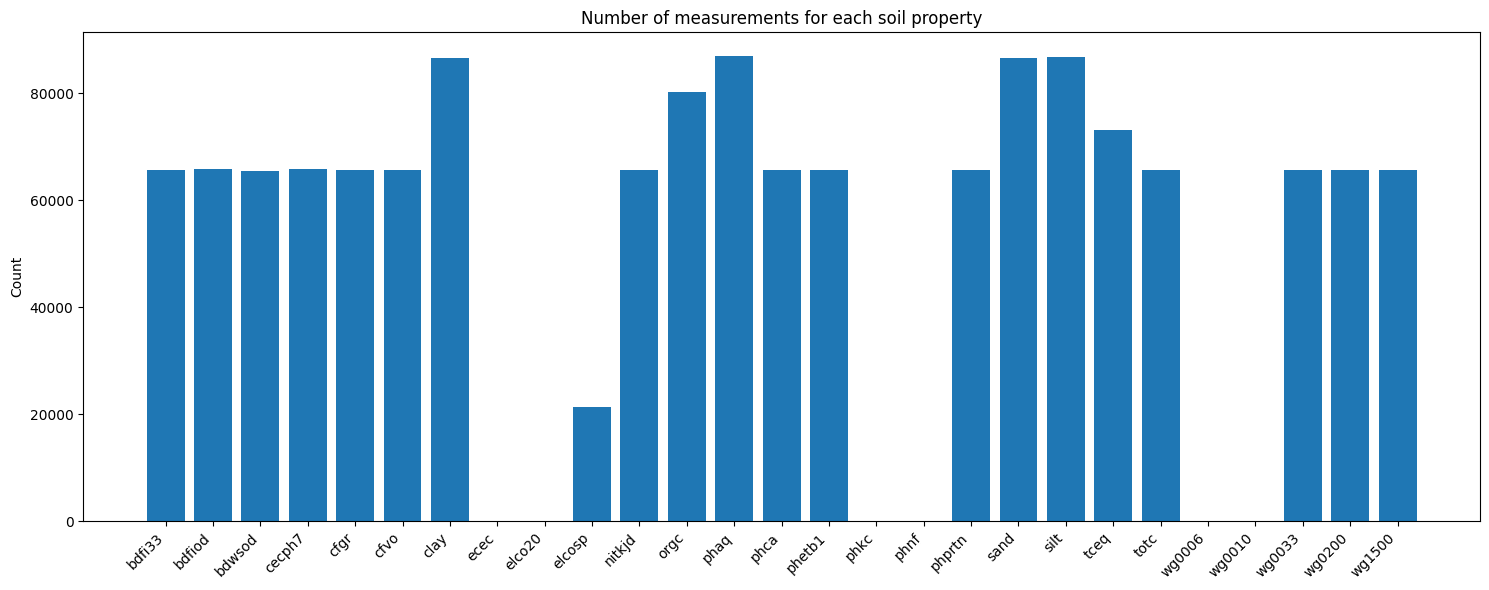

In [6]:
import matplotlib.pyplot as plt

# Get counts of non-null values for each soil property
profile_counts = {}
for column in final_df.columns:
    if column not in ['profile_id', 'latitude', 'longitude', 'upper_depth', 'lower_depth', 'date']:
        profile_counts[column] = final_df[column].notna().sum()

# Create bar plot
plt.figure(figsize=(15, 6))
plt.bar(profile_counts.keys(), profile_counts.values())
plt.xticks(rotation=45, ha='right')
plt.title('Number of measurements for each soil property')
plt.ylabel('Count')
plt.tight_layout()

In [21]:
# drop duplicates
final_df.drop_duplicates(inplace=True)
print(f"Final DataFrame has {len(final_df)} records after dropping duplicates")

# split dataset
orgc_df = final_df.drop(columns=['tceq']).copy()
tceq_df = final_df.drop(columns=['orgc']).copy()

# preprocess
def preprocess(df, target):
    # drop missing values in target column
    df = df.dropna(subset=[target])
    print(f"Layer {target} has {len(df)} records after dropping missing values")
    # drop duplicates
    df = df.drop_duplicates()
    print(f"Layer {target} has {len(df)} records after dropping duplicates")
    # drop columns with more than 60% missing values
    df = df.dropna(axis=1, thresh=len(df) * 0.6)
    print(f"Layer {target} has {len(df)} records and {df.shape[1]} columns after dropping columns with more than 60% missing values")
    # drop rows with missing values
    df = df.dropna()
    print(f"Layer {target} has {len(df)} records after dropping rows with missing values")

    # reset index
    df.reset_index(drop=True, inplace=True)

    # count unique profiles and frequency of each profile
    profile_counts = df['profile_id'].value_counts()
    print(f"Layer {target} has {len(profile_counts)} unique profiles")

    return df



Final DataFrame has 38212 records after dropping duplicates


In [22]:
# preprocess tceq
tceq_df = preprocess(tceq_df, 'tceq')

tceq_df.head()

Layer tceq has 23960 records after dropping missing values
Layer tceq has 15768 records after dropping duplicates
Layer tceq has 15768 records and 11 columns after dropping columns with more than 60% missing values
Layer tceq has 15565 records after dropping rows with missing values
Layer tceq has 2642 unique profiles


,profile_id,latitude,longitude,upper_depth,lower_depth,date,clay,phaq,sand,silt,tceq
0,1147760,18.198055,-91.536667,200,265,1991-11-4,46.8,7.7,4.8,48.4,130.0
1,1149108,15.775138,-96.732749,0,21,1986-10-12,4.0,5.5,66.0,30.0,0.0
2,1149115,15.375747,-92.924872,0,22,2004-5-27,12.0,5.9,48.0,40.0,0.0
3,1149115,15.375747,-92.924872,22,48,2004-5-27,14.0,5.9,30.0,56.0,0.0
4,1149115,15.375747,-92.924872,48,82,2004-5-27,10.0,6.4,88.0,2.0,0.0


In [23]:
# preprocess orgc
orgc_df = preprocess(orgc_df, 'orgc')

orgc_df.head()

Layer orgc has 31045 records after dropping missing values
Layer orgc has 22853 records after dropping duplicates
Layer orgc has 22853 records and 12 columns after dropping columns with more than 60% missing values
Layer orgc has 13963 records after dropping rows with missing values
Layer orgc has 4368 unique profiles


,profile_id,latitude,longitude,upper_depth,lower_depth,date,clay,elcosp,orgc,phaq,sand,silt
0,1147761,20.866667,-102.716667,63,86,1991-10-29,70.9,0.7,1.5,6.1,7.5,21.6
1,1149108,15.775138,-96.732749,0,21,1986-10-12,4.0,1.0,10.0,5.5,66.0,30.0
2,1149115,15.375747,-92.924872,0,22,2004-5-27,12.0,0.1,14.0,5.9,48.0,40.0
3,1149115,15.375747,-92.924872,22,48,2004-5-27,14.0,0.0,3.0,5.9,30.0,56.0
4,1149115,15.375747,-92.924872,48,82,2004-5-27,10.0,0.0,0.0,6.4,88.0,2.0


In [24]:
# save orgc
orgc_output_file = f"{output_path}/wosis_202312_orgc.csv"
orgc_df.to_csv(orgc_output_file, index=False)
print(f"Final DataFrame (orgc) saved to {orgc_output_file}")

# save tceq
tceq_output_file = f"{output_path}/wosis_202312_tceq.csv"
tceq_df.to_csv(tceq_output_file, index=False)
print(f"Final DataFrame (tceq) saved to {tceq_output_file}")

Final DataFrame (orgc) saved to D:/tierra/outputs/unfiltered/wosis_202312_orgc.csv
Final DataFrame (tceq) saved to D:/tierra/outputs/unfiltered/wosis_202312_tceq.csv


In [25]:
def add_soil_features(df, target):
    # set upper_depth and lower_depth as integers
    df['upper_depth'] = df['upper_depth'].astype(int)
    df['lower_depth'] = df['lower_depth'].astype(int)

    # convert to geodataframe
    gdf = gpd.GeoDataFrame(df, crs="epsg:4326", geometry=gpd.points_from_xy(df['longitude'], df['latitude']))

    print("Data converted to GeoDataFrame")
    print(gdf.head())

    # add soil type to the dataset
    soil_type_df = gpd.read_file("D:/tierra/data/soil/soiltype.geojson")
    soil_type_df = soil_type_df[['geometry', 'DESCRIPCIO']]
    soil_type_df = gpd.GeoDataFrame(soil_type_df, geometry='geometry')

    print("Soil type data loaded")
    print(soil_type_df.head())

    # merge with mexico dataset
    mex_gdf = gpd.sjoin(gdf, soil_type_df, how='left', predicate='within')

    # drop columns and reset index
    mex_gdf.drop(columns=['index_right'], errors='ignore', inplace=True)

    # rename column
    mex_gdf.rename(columns={'DESCRIPCIO': 'soil_type'}, inplace=True)

    slope_df = gpd.read_file("D:/tierra/data/soil/slope.geojson")
    slope_df = slope_df[['geometry', 'slopemean']]
    slope_df = gpd.GeoDataFrame(slope_df, geometry='geometry')

    print("Slope data loaded")
    print(slope_df.head())

    # merge with mexico dataset
    mex_gdf = gpd.sjoin(mex_gdf, slope_df, how='left', predicate='within')

    # drop columns
    mex_gdf.drop(columns=['index_right'], inplace=True, errors='ignore')

    # Load and prepare bedrock data
    bedrock_df = gpd.read_file("D:/tierra/data/soil/bedrock.geojson")
    bedrock_df = bedrock_df[['geometry', 'layer']]

    # Convert both dataframes to a projected CRS (UTM Zone appropriate for Mexico)
    bedrock_df = bedrock_df.to_crs("EPSG:32614")  # UTM Zone 14N (Central Mexico)
    mex_gdf = mex_gdf.to_crs("EPSG:32614")

    # Perform spatial join with nearest neighbor
    mex_gdf = gpd.sjoin_nearest(mex_gdf, bedrock_df, how='left')
    # mex_gdf = gpd.sjoin(mex_gdf, bedrock_df, how='left', predicate='within')

    # Drop unnecessary columns and convert back to WGS84
    mex_gdf = mex_gdf.drop(columns=['index_right']).to_crs("EPSG:4326")

    # rename the bedrock layer column
    mex_gdf.rename(columns={'layer': 'bedrock'}, inplace=True)

    print("Bedrock data loaded and merged")
    print(mex_gdf.head())

    # save the dataset generated so far
    soil_features_df_path = f"{output_path}/wosis_202312_{target}_soil_features.csv"
    mex_gdf.to_csv(soil_features_df_path, sep=",", index=False)
    print(f"Shape of the final dataset: {mex_gdf.shape}")

    # drop duplicate values
    mex_gdf.drop_duplicates(inplace=True)
    print(f"Shape of the final dataset after dropping duplicates: {mex_gdf.shape}")

    return mex_gdf

In [26]:
orgc_gdf = add_soil_features(orgc_df, 'orgc')

orgc_gdf.head()

Data converted to GeoDataFrame
   profile_id   latitude   longitude  upper_depth  lower_depth        date  \
0     1147761  20.866667 -102.716667           63           86  1991-10-29   
1     1149108  15.775138  -96.732749            0           21  1986-10-12   
2     1149115  15.375747  -92.924872            0           22   2004-5-27   
3     1149115  15.375747  -92.924872           22           48   2004-5-27   
4     1149115  15.375747  -92.924872           48           82   2004-5-27   

   clay  elcosp  orgc  phaq  sand  silt                     geometry  
0  70.9     0.7   1.5   6.1   7.5  21.6  POINT (-102.71667 20.86667)  
1   4.0     1.0  10.0   5.5  66.0  30.0   POINT (-96.73275 15.77514)  
2  12.0     0.1  14.0   5.9  48.0  40.0   POINT (-92.92487 15.37575)  
3  14.0     0.0   3.0   5.9  30.0  56.0   POINT (-92.92487 15.37575)  
4  10.0     0.0   0.0   6.4  88.0   2.0   POINT (-92.92487 15.37575)  
Soil type data loaded
                                            geometry

,profile_id,latitude,longitude,upper_depth,lower_depth,date,clay,elcosp,orgc,phaq,sand,silt,geometry,soil_type,slopemean,bedrock
0,1147761,20.866667,-102.716667,63,86,1991-10-29,70.9,0.7,1.5,6.1,7.5,21.6,POINT (-102.71667 20.86667),LUVISOL FERRICO,0.892177,rocas_sedimentarias
1,1149108,15.775138,-96.732749,0,21,1986-10-12,4.0,1.0,10.0,5.5,66.0,30.0,POINT (-96.73275 15.77514),CAMBISOL EUTRICO,0.989209,rocas_metamorficas
2,1149115,15.375747,-92.924872,0,22,2004-5-27,12.0,0.1,14.0,5.9,48.0,40.0,POINT (-92.92487 15.37575),FLUVISOL EUTRICO,0.153699,rocas_metamorficas
3,1149115,15.375747,-92.924872,22,48,2004-5-27,14.0,0.0,3.0,5.9,30.0,56.0,POINT (-92.92487 15.37575),FLUVISOL EUTRICO,0.153699,rocas_metamorficas
4,1149115,15.375747,-92.924872,48,82,2004-5-27,10.0,0.0,0.0,6.4,88.0,2.0,POINT (-92.92487 15.37575),FLUVISOL EUTRICO,0.153699,rocas_metamorficas


In [27]:
tceq_gdf = add_soil_features(tceq_df, 'tceq')

tceq_gdf.head()

Data converted to GeoDataFrame
   profile_id   latitude  longitude  upper_depth  lower_depth        date  \
0     1147760  18.198055 -91.536667          200          265   1991-11-4   
1     1149108  15.775138 -96.732749            0           21  1986-10-12   
2     1149115  15.375747 -92.924872            0           22   2004-5-27   
3     1149115  15.375747 -92.924872           22           48   2004-5-27   
4     1149115  15.375747 -92.924872           48           82   2004-5-27   

   clay  phaq  sand  silt   tceq                    geometry  
0  46.8   7.7   4.8  48.4  130.0  POINT (-91.53667 18.19806)  
1   4.0   5.5  66.0  30.0    0.0  POINT (-96.73275 15.77514)  
2  12.0   5.9  48.0  40.0    0.0  POINT (-92.92487 15.37575)  
3  14.0   5.9  30.0  56.0    0.0  POINT (-92.92487 15.37575)  
4  10.0   6.4  88.0   2.0    0.0  POINT (-92.92487 15.37575)  
Soil type data loaded
                                            geometry         DESCRIPCIO
0  MULTIPOLYGON (((-114.75709 32.7

,profile_id,latitude,longitude,upper_depth,lower_depth,date,clay,phaq,sand,silt,tceq,geometry,soil_type,slopemean,bedrock
0,1147760,18.198055,-91.536667,200,265,1991-11-4,46.8,7.7,4.8,48.4,130.0,POINT (-91.53667 18.19806),GLEYSOL PLINTICO,0.153318,rocas_sedimentarias
1,1149108,15.775138,-96.732749,0,21,1986-10-12,4.0,5.5,66.0,30.0,0.0,POINT (-96.73275 15.77514),CAMBISOL EUTRICO,0.989209,rocas_metamorficas
2,1149115,15.375747,-92.924872,0,22,2004-5-27,12.0,5.9,48.0,40.0,0.0,POINT (-92.92487 15.37575),FLUVISOL EUTRICO,0.153699,rocas_metamorficas
3,1149115,15.375747,-92.924872,22,48,2004-5-27,14.0,5.9,30.0,56.0,0.0,POINT (-92.92487 15.37575),FLUVISOL EUTRICO,0.153699,rocas_metamorficas
4,1149115,15.375747,-92.924872,48,82,2004-5-27,10.0,6.4,88.0,2.0,0.0,POINT (-92.92487 15.37575),FLUVISOL EUTRICO,0.153699,rocas_metamorficas


In [28]:
# save orgc
orgc_gdf = preprocess(orgc_gdf, 'orgc')
orgc_output_file = f"{output_path}/wosis_202312_orgc_soil_features.csv"
orgc_gdf.to_csv(orgc_output_file, index=False)
print(f"Final DataFrame (orgc) with soil features saved to {orgc_output_file}")

# save tceq
tceq_gdf = preprocess(tceq_gdf, 'tceq')
tceq_output_file = f"{output_path}/wosis_202312_tceq_soil_features.csv"
tceq_gdf.to_csv(tceq_output_file, index=False)
print(f"Final DataFrame (tceq) with soil features saved to {tceq_output_file}")

Layer orgc has 14029 records after dropping missing values
Layer orgc has 14029 records after dropping duplicates
Layer orgc has 14029 records and 16 columns after dropping columns with more than 60% missing values
Layer orgc has 13917 records after dropping rows with missing values
Layer orgc has 4336 unique profiles
Final DataFrame (orgc) with soil features saved to D:/tierra/outputs/unfiltered/wosis_202312_orgc_soil_features.csv
Layer tceq has 7442 records after dropping missing values
Layer tceq has 7442 records after dropping duplicates
Layer tceq has 7442 records and 15 columns after dropping columns with more than 60% missing values
Layer tceq has 7370 records after dropping rows with missing values
Layer tceq has 2619 unique profiles
Final DataFrame (tceq) with soil features saved to D:/tierra/outputs/unfiltered/wosis_202312_tceq_soil_features.csv


In [29]:
def check_unique_values(df, column):
    # check how many unique upper_depth and lower_depth values for each profile
    unique_depths = df.groupby('profile_id').agg({
        'upper_depth': 'nunique',
        'lower_depth': 'nunique'
    }).reset_index()

    print("Unique upper_depth and lower_depth values for each profile:")
    print(unique_depths)


check_unique_values(orgc_gdf, 'orgc')
check_unique_values(tceq_gdf, 'tceq')

Unique upper_depth and lower_depth values for each profile:
      profile_id  upper_depth  lower_depth
0        1147761            1            1
1        1149108            1            1
2        1149115            5            5
3        1149116            5            5
4        1149117            2            2
...          ...          ...          ...
4331     1671313            1            1
4332     1671314            3            3
4333     1671318            4            4
4334     1671321            6            6
4335     1671322            4            4

[4336 rows x 3 columns]
Unique upper_depth and lower_depth values for each profile:
      profile_id  upper_depth  lower_depth
0        1147760            1            1
1        1149108            1            1
2        1149115            5            5
3        1149116            3            3
4        1149117            2            2
...          ...          ...          ...
2614     1671286            3         

In [30]:
def process_depths(df):
    # check how many unique upper_depth and lower_depth values for each profile
    unique_depths = df.groupby('profile_id').agg({
        'upper_depth': 'nunique',
        'lower_depth': 'nunique'
    }).reset_index()

    # filter profiles with single upper_depth and lower_depth
    single_depth_profiles = unique_depths[(unique_depths['upper_depth'] == 1) & (unique_depths['lower_depth'] == 1)]
    print(f"Profiles with single upper_depth and lower_depth: {len(single_depth_profiles)}")

    # drop profiles with single upper_depth and lower_depth
    df = df[~df['profile_id'].isin(single_depth_profiles['profile_id'])]
    print(f"Shape of the final dataset after dropping profiles with single upper_depth and lower_depth: {df.shape}")

    # drop profiles with duplicate upper_depth and lower_depth
    duplicate_depths = df[df.duplicated(subset=['profile_id', 'upper_depth', 'lower_depth'], keep=False)]
    print(f"Profiles with duplicate upper_depth and lower_depth: {len(duplicate_depths)}")

    return df

In [31]:
orgc_gdf = process_depths(orgc_gdf)

# save orgc
orgc_output_file = f"{output_path}/wosis_202312_orgc_soil_features_cleaned.csv"
orgc_gdf.to_csv(orgc_output_file, index=False)
print(f"Final DataFrame (orgc) with soil features saved to {orgc_output_file}")

Profiles with single upper_depth and lower_depth: 1003
Shape of the final dataset after dropping profiles with single upper_depth and lower_depth: (12908, 16)
Profiles with duplicate upper_depth and lower_depth: 112
Final DataFrame (orgc) with soil features saved to D:/tierra/outputs/unfiltered/wosis_202312_orgc_soil_features_cleaned.csv


In [32]:
tceq_gdf = process_depths(tceq_gdf)

# save tceq
tceq_output_file = f"{output_path}/wosis_202312_tceq_soil_features_cleaned.csv"
tceq_gdf.to_csv(tceq_output_file, index=False)
print(f"Final DataFrame (tceq) with soil features saved to {tceq_output_file}")

Profiles with single upper_depth and lower_depth: 742
Shape of the final dataset after dropping profiles with single upper_depth and lower_depth: (6622, 15)
Profiles with duplicate upper_depth and lower_depth: 86
Final DataFrame (tceq) with soil features saved to D:/tierra/outputs/unfiltered/wosis_202312_tceq_soil_features_cleaned.csv
